### Getting started with Detectron2

### Installing Detectron2

In [1]:
!python -m pip install pyyaml==5.1
import sys, os, distutils.core
# Note: This is a faster way to install detectron2 in Colab, but it does not include all functionalities (e.g. compiled operators).
# See https://detectron2.readthedocs.io/tutorials/install.html for full installation instructions
!git clone 'https://github.com/facebookresearch/detectron2'
dist = distutils.core.run_setup("./detectron2/setup.py")
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0, os.path.abspath('./detectron2'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.2/274.2 kB 1.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 15912, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 15912 (delta 73), reused 31 (delta 30), pack-reused 15786 (from 3)
Receiving objects: 100% (15912/15912), 6.44 MiB | 11.05 MiB/s, done.
Resolving deltas: 100% (11574/11574), done.
Ignoring dataclasses: markers 'python_version < "3.7"' don't match your 

In [2]:
import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
torch:  2.8 ; cuda:  cu126
detectron2: 0.6


### Imports

In [3]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random
from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

# Run Multiple pre-trained detectron2 models

Get our Inference Test Image

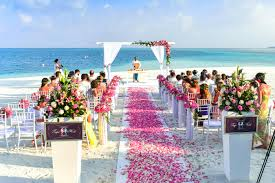

In [5]:
im = cv2.imread("/content/images.jpg")
cv2_imshow(im)

### Loading the Pretrained Model & Config File

In [6]:
cfg = get_cfg()
# add project-specific config (e.g., TensorMask) here if you're not running a model in detectron2's core library
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_1x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
# Find a model from detectron2's model zoo. You can use the https://dl.fbaipublicfiles... url as well
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_1x.yaml")
predictor = DefaultPredictor(cfg)
outputs = predictor(im)

[08/31 19:19:14 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-Detection/faster_rcnn_R_50_FPN_1x/137257794/model_final_b275ba.pkl ...


model_final_b275ba.pkl: 167MB [00:08, 19.4MB/s]                           
/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


### Let's look in the model output

In [7]:
# look at the outputs. See https://detectron2.readthedocs.io/tutorials/models.html#model-output-format for specification
print(outputs["instances"].pred_classes)
print(outputs["instances"].pred_boxes)

tensor([56, 56,  0,  0,  0,  0,  0, 72,  0,  0,  0,  0,  0,  0,  0, 58,  0],
       device='cuda:0')
Boxes(tensor([[202.8374, 107.1853, 221.9670, 140.7435],
        [193.4293, 105.6361, 210.1018, 126.9811],
        [ 30.2455,  77.1090,  50.9411, 105.9492],
        [ 53.5406,  58.5729,  62.4804,  76.6497],
        [166.8367,  69.9476, 177.1094,  82.7224],
        [249.8282,  72.7245, 272.1964, 140.2435],
        [ 78.2947,  72.9076,  91.0000,  96.1912],
        [223.5113, 132.1161, 254.0063, 181.4539],
        [131.2436,  56.9977, 141.1113,  82.8096],
        [ 32.0819,  96.2442,  47.1919, 147.6876],
        [ 47.5098,  74.7455,  58.6444,  93.7245],
        [187.5166,  79.5358, 200.4448,  99.0823],
        [157.5502,  72.8159, 175.8355, 106.1737],
        [ 73.2369,  68.8936,  81.1783,  82.0131],
        [175.6798,  74.0771, 183.6763,  92.7392],
        [219.6252,  69.3203, 263.1793, 135.6246],
        [ 93.0520,  76.9597, 111.2188, 147.2438]], device='cuda:0'))


### Visualizing the predicted image

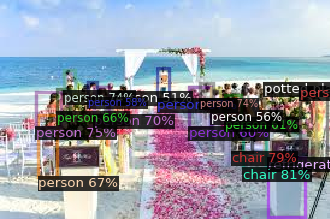

In [8]:
# We can use `Visualizer` to draw the predictions on the image.
v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2_imshow(out.get_image()[:, :, ::-1])

### Inferencing with Faster RCNN Resnet101 Model

### Loading the Pretrained Model & Config File

In [9]:
cfg = get_cfg()
# add project-specific config (e.g., TensorMask) here if you're not running a model in detectron2's core library
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
# Find a model from detectron2's model zoo. You can use the https://dl.fbaipublicfiles... url as well
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_101_FPN_3x.yaml")
predictor = DefaultPredictor(cfg)
outputs = predictor(im)

[08/31 19:25:11 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-Detection/faster_rcnn_R_101_FPN_3x/137851257/model_final_f6e8b1.pkl ...


model_final_f6e8b1.pkl: 243MB [00:12, 20.3MB/s]                           


In [10]:
# look at the outputs. See https://detectron2.readthedocs.io/tutorials/models.html#model-output-format for specification
print(outputs["instances"].pred_classes)
print(outputs["instances"].pred_boxes)

tensor([ 0, 56,  0,  0,  0,  0, 75,  0,  0,  0, 75,  0,  0,  0,  0,  0,  0, 58,
         0], device='cuda:0')
Boxes(tensor([[ 30.5165,  77.2028,  50.9108, 104.1969],
        [202.5384, 106.9053, 222.4245, 142.2126],
        [250.3129,  72.9641, 272.4215, 133.4981],
        [ 88.2839,  69.4957,  97.0572,  81.5391],
        [ 53.6187,  58.2751,  63.0084,  70.4654],
        [ 78.8957,  72.9266,  91.2745,  94.0323],
        [184.9532, 108.7402, 193.2068, 139.2440],
        [ 47.3069,  75.1313,  57.8207,  91.5804],
        [ 97.8891,  71.0449, 106.4553,  82.8681],
        [186.4092,  77.3681, 200.5915,  98.7964],
        [176.7917,  99.7051, 186.2696, 128.0446],
        [166.2614,  69.6106, 176.2506,  83.4872],
        [199.8159,  68.8966, 208.8347,  83.5340],
        [ 84.4998,  79.3805, 103.2615, 122.2841],
        [ 71.8931,  68.9830,  81.5307,  84.5975],
        [217.7516,  73.9053, 227.5331,  84.8502],
        [175.2891,  74.2383, 182.4822,  84.6609],
        [217.5327,  75.5650, 260.4

## Visualizing the predicted image

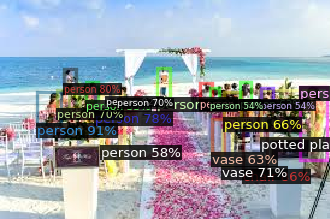

In [11]:
v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2_imshow(out.get_image()[:, :, ::-1])